# Odev 4 - CLIP Zero-Shot and DINOv2 Linear Probe on ISIC2019

This notebook compares zero-shot CLIP and frozen DINOv2 + linear probe on the ISIC2019 split stored under `C:/Users/emirh/Desktop/Projects/datasets/input_sk`.

Sections:
- Dataset summary
- CLIP zero-shot classification
- Prompt ablation
- DINOv2 frozen backbone + linear probe
- Comparison with earlier models
- Error analysis

In [13]:
%pip install -q open_clip_torch
import json
import math
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, AutoModel
from open_clip import create_model_from_pretrained, get_tokenizer

pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

DATA_ROOT = Path(r'C:/Users/emirh/Desktop/Projects/datasets/input_sk')
TRAIN_DIR = DATA_ROOT / 'train'
VAL_DIR = DATA_ROOT / 'val'
TEST_DIR = DATA_ROOT / 'test'

assert TRAIN_DIR.is_dir() and VAL_DIR.is_dir() and TEST_DIR.is_dir(), 'Dataset split folders not found.'

Note: you may need to restart the kernel to use updated packages.
Device: cuda


In [16]:
class ImageFolderWithPath(datasets.ImageFolder):
    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path, _ = self.samples[index]
        return image, label, path

def pil_collate(batch):
    images, labels, paths = zip(*batch)
    return list(images), torch.tensor(labels, dtype=torch.long), list(paths)

def split_summary(dataset):
    counts = np.bincount([label for _, label in dataset.samples], minlength=len(dataset.classes))
    return pd.DataFrame({'class': dataset.classes, 'count': counts, 'split_total': len(dataset)})

train_ds = ImageFolderWithPath(str(TRAIN_DIR))
val_ds = ImageFolderWithPath(str(VAL_DIR))
test_ds = ImageFolderWithPath(str(TEST_DIR))

class_names = train_ds.classes

class_full_names = {
    'AK': 'Actinic keratosis',
    'BCC': 'Basal cell carcinoma',
    'BKL': 'Benign keratosis',
    'DF': 'Dermatofibroma',
    'MEL': 'Melanoma',
    'NV': 'Melanocytic nevus',
    'SCC': 'Squamous cell carcinoma',
    'VASC': 'Vascular lesion',
}

short_prompts = {
    'AK': ['Actinic keratosis'],
    'BCC': ['Basal cell carcinoma'],
    'BKL': ['Benign keratosis'],
    'DF': ['Dermatofibroma'],
    'MEL': ['Melanoma'],
    'NV': ['Melanocytic nevus'],
    'SCC': ['Squamous cell carcinoma'],
    'VASC': ['Vascular lesion'],
}

descriptive_prompts = {
    'AK': ['a dermoscopic image of actinic keratosis'],
    'BCC': ['a dermoscopic image of basal cell carcinoma'],
    'BKL': ['a dermoscopic image of benign keratosis'],
    'DF': ['a dermoscopic image of dermatofibroma'],
    'MEL': ['a dermoscopic image of melanoma'],
    'NV': ['a dermoscopic image of melanocytic nevus'],
    'SCC': ['a dermoscopic image of squamous cell carcinoma'],
    'VASC': ['a dermoscopic image of vascular lesion'],
}

summary_df = pd.concat([
    split_summary(train_ds).assign(split='train'),
    split_summary(val_ds).assign(split='val'),
    split_summary(test_ds).assign(split='test')
])

## CLIP zero-shot classification

The notebook uses a general CLIP model and tests two prompt sets: a short baseline and a more descriptive medical prompt set. The descriptive set is the one to report in the assignment, and the short set gives a simple prompt ablation.

In [17]:
clip_model_name = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
clip_model, clip_preprocess = create_model_from_pretrained(clip_model_name)
clip_tokenizer = get_tokenizer(clip_model_name)
clip_model = clip_model.to(device)
clip_model.eval()

def normalize(x):
    return x / x.norm(dim=-1, keepdim=True).clamp_min(1e-12)

def build_text_features(prompt_dict):
    ordered_classes = list(prompt_dict.keys())
    class_features = []

    with torch.no_grad():
        for cls in ordered_classes:
            prompt = prompt_dict[cls][0]
            text_tokens = clip_tokenizer([prompt], context_length=256).to(device)
            _, text_features, _ = clip_model(None, text_tokens)
            text_features = normalize(text_features)
            class_features.append(text_features.squeeze(0))

    class_features = torch.stack(class_features, dim=0)
    class_features = normalize(class_features)
    return ordered_classes, class_features

def evaluate_clip_zero_shot(dataset, prompt_dict, batch_size=32, num_workers=0):
    ordered_classes, text_features = build_text_features(prompt_dict)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=pil_collate)

    y_true = []
    y_pred = []
    y_conf = []
    error_rows = []

    with torch.no_grad():
        for images, labels, paths in tqdm(loader, desc='BiomedCLIP inference'):
            image_batch = torch.stack([clip_preprocess(image) for image in images]).to(device)
            image_features, _, _ = clip_model(image_batch, None)
            image_features = normalize(image_features)
            logits = clip_model.logit_scale.exp() * image_features @ text_features.T
            probs = logits.softmax(dim=-1)
            pred_idx = probs.argmax(dim=-1)

            y_true.extend(labels.tolist())
            y_pred.extend(pred_idx.tolist())

            top_prob, top_idx = probs.max(dim=-1)
            y_conf.extend(top_prob.tolist())

            topk_prob, topk_idx = probs.topk(k=min(3, probs.shape[-1]), dim=-1)

            for i, (true_id, pred_id, conf, path) in enumerate(zip(labels.tolist(), pred_idx.tolist(), top_prob.tolist(), paths)):
                if true_id != pred_id:
                    top3 = [f'{ordered_classes[idx]}:{prob:.3f}' for idx, prob in zip(topk_idx[i].tolist(), topk_prob[i].tolist())]
                    error_rows.append({'path': path, 'true': ordered_classes[true_id], 'pred': ordered_classes[pred_id], 'confidence': conf, 'top3': ' | '.join(top3)})

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(ordered_classes))))
    report = classification_report(y_true, y_pred, target_names=ordered_classes, zero_division=0, output_dict=True)
    error_df = pd.DataFrame(error_rows).sort_values('confidence', ascending=False).reset_index(drop=True)

    return {'prompt_name': None, 'class_order': ordered_classes, 'accuracy': float(acc), 'macro_f1': float(macro_f1), 'confusion_matrix': cm, 'classification_report': report, 'errors': error_df, 'y_true': np.array(y_true), 'y_pred': np.array(y_pred), 'y_conf': np.array(y_conf)}

clip_results = []

for prompt_name, prompt_dict in [('descriptive', descriptive_prompts), ('short', short_prompts)]:
    result = evaluate_clip_zero_shot(test_ds, prompt_dict, batch_size=32, num_workers=0)
    result['prompt_name'] = prompt_name
    clip_results.append(result)

clip_summary_df = pd.DataFrame([{'prompt_set': r['prompt_name'], 'accuracy': r['accuracy'], 'macro_f1': r['macro_f1'], 'errors': len(r['errors'])} for r in clip_results])
display(clip_summary_df.sort_values('macro_f1', ascending=False))

best_clip = max(clip_results, key=lambda x: x['macro_f1'])
clip_cm = pd.DataFrame(best_clip['confusion_matrix'], index=class_names, columns=class_names)
display(clip_cm)
display(pd.DataFrame(best_clip['classification_report']).T.loc[class_names + ['macro avg', 'weighted avg']])

BiomedCLIP inference: 100%|██████████| 159/159 [01:21<00:00,  1.96it/s]


,prompt_set,accuracy,macro_f1,errors
0,descriptive,0.195185,0.148981,4078
1,short,0.160450,0.091500,4254


,AK,BCC,BKL,DF,MEL,NV,SCC,VASC
AK,29,15,1,91,12,7,10,8
BCC,55,107,3,300,36,57,43,64
BKL,52,78,3,205,78,86,12,11
DF,3,6,0,31,1,4,1,2
MEL,46,146,9,215,170,282,23,13
NV,55,168,17,1371,300,616,8,40
SCC,19,21,0,44,3,7,24,8
VASC,0,9,0,20,3,8,2,9


,precision,recall,f1-score,support
AK,0.111969,0.167630,0.134259,173.0
BCC,0.194545,0.160902,0.176132,665.0
BKL,0.090909,0.005714,0.010753,525.0
DF,0.013614,0.645833,0.026667,48.0
MEL,0.281924,0.188053,0.225614,904.0
NV,0.577320,0.239223,0.338276,2575.0
SCC,0.195122,0.190476,0.192771,126.0
VASC,0.058065,0.176471,0.087379,51.0
macro avg,0.190433,0.221788,0.148981,5067.0
weighted avg,0.388026,0.195185,0.246900,5067.0


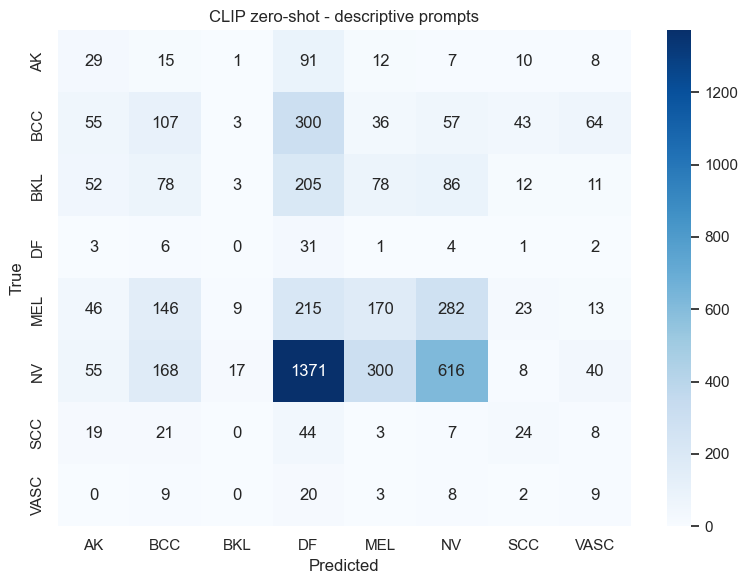

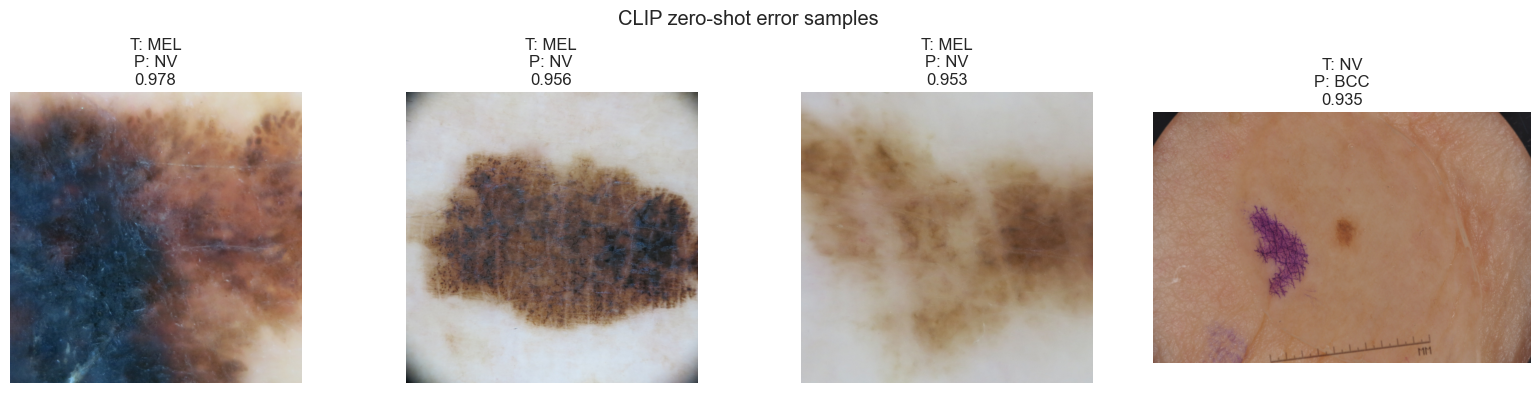

,true,pred,count
37,NV,DF,1371
9,BCC,DF,300
38,NV,MEL,300
31,MEL,NV,282
30,MEL,DF,215
16,BKL,DF,205
35,NV,BCC,168
28,MEL,BCC,146
2,AK,DF,91
18,BKL,NV,86


In [18]:
def plot_confusion(cm, labels, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def show_error_samples(dataset, error_df, n=4, title=''):
    if error_df.empty:
        print('No errors to show.')
        return
    rows = error_df.head(n).copy()
    fig, axes = plt.subplots(1, len(rows), figsize=(4 * len(rows), 4))
    if len(rows) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, rows.iterrows()):
        image = Image.open(row['path']).convert('RGB')
        ax.imshow(image)
        ax.set_title(f"T: {row['true']}\nP: {row['pred']}\n{row['confidence']:.3f}")
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_confusion(best_clip['confusion_matrix'], class_names, f"CLIP zero-shot - {best_clip['prompt_name']} prompts")
show_error_samples(test_ds, best_clip['errors'], n=4, title='CLIP zero-shot error samples')

top_confusions = []
cm = best_clip['confusion_matrix']
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            top_confusions.append({'true': class_names[i], 'pred': class_names[j], 'count': int(cm[i, j])})
top_confusions_df = pd.DataFrame(top_confusions).sort_values('count', ascending=False).head(10)
display(top_confusions_df)

## DINOv2 frozen backbone + linear probe

This section extracts features from a frozen DINOv2 backbone and trains a simple logistic regression classifier on top. The backbone is kept fixed, so the classifier tests how separable the raw visual representation already is.

In [19]:
dinov2_candidates = ['facebook/dinov2-small', 'facebook/dinov2-base']
dinov2_model_name = None
dinov2_processor = None
dinov2_model = None
last_error = None

for candidate in dinov2_candidates:
    try:
        dinov2_processor = AutoImageProcessor.from_pretrained(candidate)
        dinov2_model = AutoModel.from_pretrained(candidate).to(device)
        dinov2_model.eval()
        dinov2_model_name = candidate
        break
    except Exception as exc:
        last_error = exc

if dinov2_model is None:
    raise RuntimeError(f'Could not load a DINOv2 model. Last error: {last_error}')

print('Loaded DINOv2 backbone:', dinov2_model_name)

def extract_embeddings(dataset, processor, model, batch_size=16, num_workers=0):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=pil_collate)
    features = []
    labels = []
    paths = []

    with torch.no_grad():
        for images, batch_labels, batch_paths in tqdm(loader, desc='Feature extraction'):
            inputs = processor(images=images, return_tensors='pt').to(device)
            outputs = model(**inputs)
            if hasattr(outputs, 'last_hidden_state'):
                embedding = outputs.last_hidden_state[:, 0, :]
            elif hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
                embedding = outputs.pooler_output
            else:
                embedding = outputs[0][:, 0, :]
            features.append(embedding.cpu().numpy())
            labels.extend(batch_labels.tolist())
            paths.extend(batch_paths)

    return np.concatenate(features, axis=0), np.array(labels), paths

X_train, y_train, train_paths = extract_embeddings(train_ds, dinov2_processor, dinov2_model, batch_size=16)
X_val, y_val, val_paths = extract_embeddings(val_ds, dinov2_processor, dinov2_model, batch_size=16)
X_test, y_test, test_paths = extract_embeddings(test_ds, dinov2_processor, dinov2_model, batch_size=16)

print('Embedding shapes:', X_train.shape, X_val.shape, X_test.shape)

import torch.nn as nn
import torch.optim as optim

# Simple PyTorch linear probe using a single nn.Linear layer
class TorchLinearProbe:
    def __init__(self, input_dim, num_classes, device=device, lr=1e-3, weight_decay=0.0):
        self.device = device
        self.model = nn.Linear(input_dim, num_classes).to(device)
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        self._is_trained = False

    def fit(self, X, y, epochs=30, batch_size=256, verbose=False):
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        y_tensor = torch.tensor(y, dtype=torch.long).to(self.device)
        dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
        self.model.train()
        for epoch in range(epochs):
            epoch_loss = 0.0
            for xb, yb in loader:
                self.optimizer.zero_grad()
                logits = self.model(xb)
                loss = self.criterion(logits, yb)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item() * xb.size(0)
            if verbose:
                print(f'Epoch {epoch+1}/{epochs} loss: {epoch_loss / len(dataset):.4f}')
        self._is_trained = True

    def predict_proba(self, X):
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            logits = self.model(X_tensor)
            probs = torch.softmax(logits, dim=-1)
        return probs.cpu().numpy()

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

# Instantiate and train the torch linear probe
linear_probe = TorchLinearProbe(input_dim=X_train.shape[1], num_classes=len(class_names), device=device, lr=1e-3)
linear_probe.fit(X_train, y_train, epochs=30, batch_size=256, verbose=True)

val_pred = linear_probe.predict(X_val)
test_pred = linear_probe.predict(X_test)
val_proba = linear_probe.predict_proba(X_val)
test_proba = linear_probe.predict_proba(X_test)

def summarize_predictions(y_true, y_pred, y_proba, paths, class_names):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0, output_dict=True)

    error_rows = []
    for idx, (yt, yp) in enumerate(zip(y_true, y_pred)):
        if yt != yp:
            probs = y_proba[idx]
            top3_idx = np.argsort(probs)[-3:][::-1]
            top3 = ' | '.join([f'{class_names[i]}:{probs[i]:.3f}' for i in top3_idx])
            error_rows.append({
                'path': paths[idx],
                'true': class_names[yt],
                'pred': class_names[yp],
                'confidence': float(probs[yp]),
                'top3': top3,
            })
    error_df = pd.DataFrame(error_rows).sort_values('confidence', ascending=False).reset_index(drop=True)
    return {
        'accuracy': float(acc),
        'macro_f1': float(macro_f1),
        'confusion_matrix': cm,
        'classification_report': report,
        'errors': error_df,
    }

dino_val = summarize_predictions(y_val, val_pred, val_proba, val_paths, class_names)
dino_test = summarize_predictions(y_test, test_pred, test_proba, test_paths, class_names)

dino_summary_df = pd.DataFrame([
    {'split': 'val', 'accuracy': dino_val['accuracy'], 'macro_f1': dino_val['macro_f1'], 'errors': len(dino_val['errors'])},
    {'split': 'test', 'accuracy': dino_test['accuracy'], 'macro_f1': dino_test['macro_f1'], 'errors': len(dino_test['errors'])},
])
display(dino_summary_df)
display(pd.DataFrame(dino_test['confusion_matrix'], index=class_names, columns=class_names))
display(pd.DataFrame(dino_test['classification_report']).T.loc[class_names + ['macro avg', 'weighted avg']])

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 9867.70it/s]


Loaded DINOv2 backbone: facebook/dinov2-small


Feature extraction: 100%|██████████| 317/317 [01:21<00:00,  3.90it/s]


Embedding shapes: (17732, 384) (2532, 384) (5067, 384)
Epoch 1/30 loss: 1.2665
Epoch 2/30 loss: 0.9174
Epoch 3/30 loss: 0.8590
Epoch 4/30 loss: 0.8281
Epoch 5/30 loss: 0.8090
Epoch 6/30 loss: 0.7878
Epoch 7/30 loss: 0.7762
Epoch 8/30 loss: 0.7668
Epoch 9/30 loss: 0.7588
Epoch 10/30 loss: 0.7552
Epoch 11/30 loss: 0.7487
Epoch 12/30 loss: 0.7421
Epoch 13/30 loss: 0.7382
Epoch 14/30 loss: 0.7362
Epoch 15/30 loss: 0.7285
Epoch 16/30 loss: 0.7268
Epoch 17/30 loss: 0.7226
Epoch 18/30 loss: 0.7192
Epoch 19/30 loss: 0.7181
Epoch 20/30 loss: 0.7161
Epoch 21/30 loss: 0.7116
Epoch 22/30 loss: 0.7130
Epoch 23/30 loss: 0.7094
Epoch 24/30 loss: 0.7090
Epoch 25/30 loss: 0.7053
Epoch 26/30 loss: 0.7029
Epoch 27/30 loss: 0.7020
Epoch 28/30 loss: 0.6991
Epoch 29/30 loss: 0.7001
Epoch 30/30 loss: 0.7030


,split,accuracy,macro_f1,errors
0,val,0.723144,0.546482,701
1,test,0.713045,0.559783,1454


,AK,BCC,BKL,DF,MEL,NV,SCC,VASC
AK,72,36,27,0,12,10,16,0
BCC,42,457,36,0,39,66,24,1
BKL,24,44,231,1,85,125,14,1
DF,0,4,2,16,5,18,3,0
MEL,16,43,53,1,470,307,14,0
NV,4,51,79,6,133,2297,2,3
SCC,10,32,11,0,24,10,39,0
VASC,0,7,1,0,0,12,0,31


,precision,recall,f1-score,support
AK,0.428571,0.416185,0.422287,173.0
BCC,0.678042,0.687218,0.682599,665.0
BKL,0.525000,0.440000,0.478756,525.0
DF,0.666667,0.333333,0.444444,48.0
MEL,0.611979,0.519912,0.562201,904.0
NV,0.807381,0.892039,0.847601,2575.0
SCC,0.348214,0.309524,0.327731,126.0
VASC,0.861111,0.607843,0.712644,51.0
macro avg,0.615871,0.525757,0.559783,5067.0
weighted avg,0.701143,0.713045,0.704185,5067.0


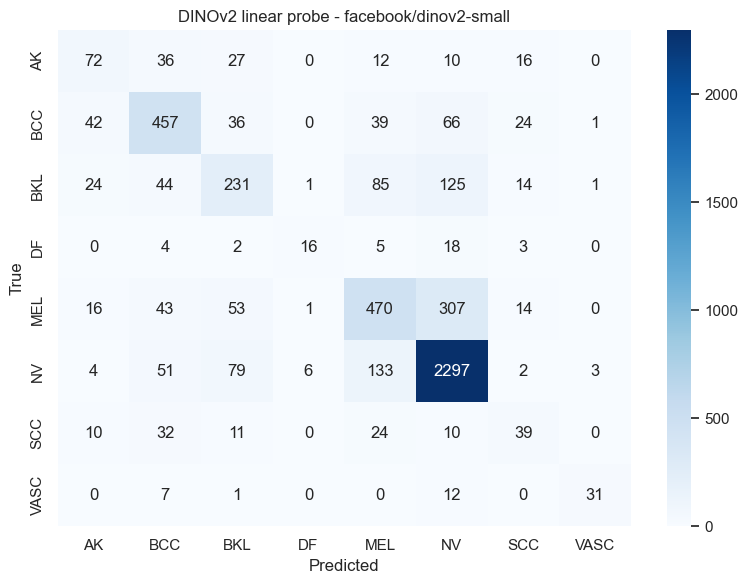

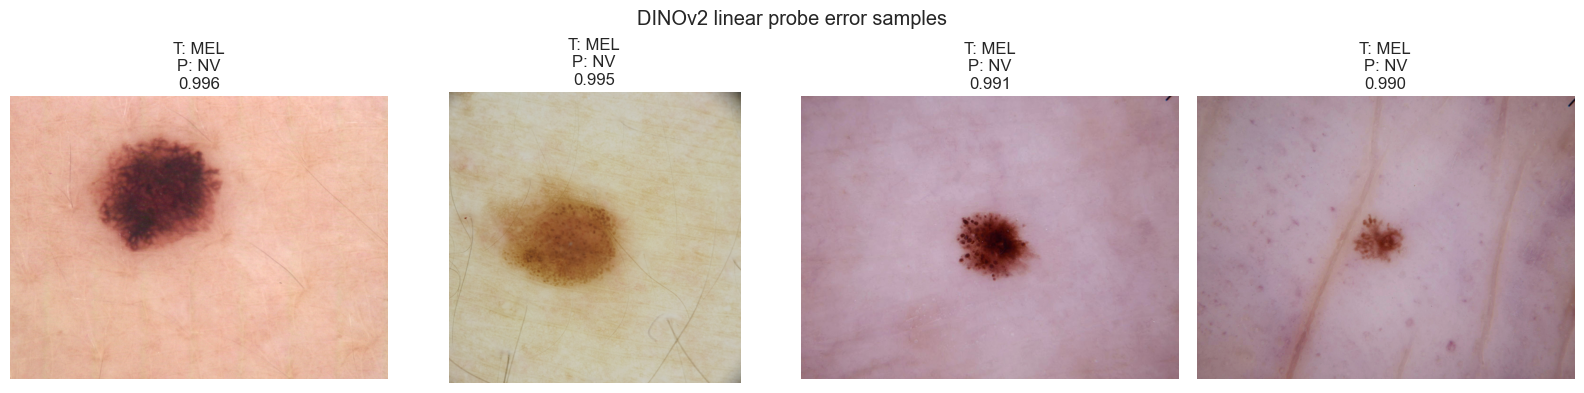

,true,pred,count
27,MEL,NV,307
33,NV,MEL,133
15,BKL,NV,125
14,BKL,MEL,85
31,NV,BKL,79
8,BCC,NV,66
25,MEL,BKL,53
30,NV,BCC,51
12,BKL,BCC,44
24,MEL,BCC,43


In [20]:
plot_confusion(dino_test['confusion_matrix'], class_names, f'DINOv2 linear probe - {dinov2_model_name}')
show_error_samples(test_ds, dino_test['errors'], n=4, title='DINOv2 linear probe error samples')

top_confusions = []
cm = dino_test['confusion_matrix']
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            top_confusions.append({'true': class_names[i], 'pred': class_names[j], 'count': int(cm[i, j])})
dino_confusions_df = pd.DataFrame(top_confusions).sort_values('count', ascending=False).head(10)
display(dino_confusions_df)